```ocaml
T2I
├── clip_encoder
│   ├── self_attn
│   └── mlp
├── t5_encoder
│   ├── self_attn
│   └── mlp
|       ├──up_a
|       ├──up_b
|       └──down
├── unet
│   ├── self_attn
│   └── cross_attn
├── single_stream_block
│   └──attn
├── dual_stream_block
|    └──attn
└── final_head
```

```ocaml
Stitcher
├── skip_module
├── run_diffusion_lens
├── graft
└── map

SAE
├── train (wrapper around sparsify)
├── load (option to edit the model to include saes)
├── intervene (scale,ablate or set a value)
└── saeBench metrics

Mapper
└── Affine and Autoencoder mapper training
```

### Pending
- Identify **which modules return tuple vs tensor** (using scan on dummy input)
- Viz. - visualization (plugin existing libraries)
- **Extract within-module tensors** using the .source (low priority)
- **SAE high-level functionality** 
- unit tests
-


### dependencies

In [1]:
import os
os.chdir("..")
from t2Interp.T2I import T2IModel
from t2Interp.intervention import EncoderAttentionIntervention, ScalingAttentionIntervention #, InterventionRunner

/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `PYTORCH_TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/nnsight/__init__.py:47: UserWarning: nnsight.trace is deprecated as of v0.5.0 and will be removed in a future version.
  warnings.warn(deprecation_message)


### loading a model

In [2]:
model = T2IModel("CompVis/stable-diffusion-v1-4", device="cuda:0", dtype="float16")

2025-09-12 20:17:03.776 | INFO     | t2Interp.T2I:__init__:102 - Enforcing eager attention implementation for attention pattern tracing. The HF default would be to use sdpa if available. To use sdpa, set attn_implementation='sdpa' or None to use the HF default.
Keyword arguments {'attn_implementation': 'eager', 'tokenizer_kwargs': {}, 'trust_remote_code': False} are not expected by StableDiffusionPipeline and will be ignored.
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 21.71it/s]


### model accessors

In [3]:
# list east access properties
model._wrappers

{'text_encoder_2': <t2Interp.clip_encoder.ClipEncoder at 0x7fee56eb5050>,
 'unet_2': UNet:
   Down Blocks: 6
     [00] in | self_attn_in | self_attn_out | cross_attn_in | cross_attn_out | mlp_in | mlp_out | out | cross_q_in | cross_k_in | cross_v_in | self_q_in | self_k_in | self_v_in |cross_q_out | cross_k_out | cross_v_out | self_q_out | self_k_out | self_v_out
     [01] in | self_attn_in | self_attn_out | cross_attn_in | cross_attn_out | mlp_in | mlp_out | out | cross_q_in | cross_k_in | cross_v_in | self_q_in | self_k_in | self_v_in |cross_q_out | cross_k_out | cross_v_out | self_q_out | self_k_out | self_v_out
     [02] in | self_attn_in | self_attn_out | cross_attn_in | cross_attn_out | mlp_in | mlp_out | out | cross_q_in | cross_k_in | cross_v_in | self_q_in | self_k_in | self_v_in |cross_q_out | cross_k_out | cross_v_out | self_q_out | self_k_out | self_v_out
     [03] in | self_attn_in | self_attn_out | cross_attn_in | cross_attn_out | mlp_in | mlp_out | out | cross_q_in | cro

## Intervention

In [4]:
from utils.inference import Inference, InferenceSpec
from t2Interp.intervention import run_intervention
# from ray_runner import run_multiple_inferences

#### attention head corrupted intervention

In [7]:
# patch explorer (patch cross attention heads and measure impact on generated image)
# selection = {"spatial_location":[1,2,3,4],"heads":[1,2,3,4]}
spatial_location = [1,2,3,4]
heads=[1,2,3,4]
envoys = [block.cross_attn_out.module for block in model.unet_2.down_blocks]

# create intervention object for each combination of spatial location, head and envoy
intervention_objs=[]
# for en in envoys:
#     for sl in spatial_location:
#         for h in heads:
#             selection = {"spatial_location":[sl],"heads":[h]}
#             intervention_objs.append(EncoderAttentionIntervention(replacement_text="", model=model,envoys=[en],selection=selection))
#             break
#         break
#     break

# intervene on all of them together
intervention_objs.append(EncoderAttentionIntervention(replacement_text="", model=model,envoys=envoys,selection={"spatial_location":spatial_location,"heads":heads}))

# using ray (parallelization on multiple gpus, dashboard etc.)
# int_runner=InterventionRunner(model=model)

# create inference spec
# specs=[]
# for obj in intervention_objs:
#     specs.append(InferenceSpec(name=f"sl{obj.selection['spatial_location'][0]}_h{obj.selection['heads'][0]}_{obj.envoys[0].__class__.__name__}", 
#                                inference_fn= int_runner.run,
#                                kwargs={"model":model, "prompt":"unicorn", "n_steps":50, "seed":40, "interventions":[obj]}))
    
# run inferences
# inferences = run_multiple_inferences(specs, {"n_gpus":1})

# without ray
specs=[]
for obj in intervention_objs:
    specs.append(InferenceSpec(name=f"sl{obj.selection['spatial_location'][0]}_h{obj.selection['heads'][0]}_{obj.envoys[0].__class__.__name__}", 
                               inference_fn= run_intervention,
                               kwargs={"model":model, "prompt":"unicorn", "n_steps":50, "start_step":0, "end_step":50, "seed":40, "interventions":[obj]}))

out=[]   
for spec in specs:
    inference = Inference(spec)
    out.append(inference.predict())

100%|██████████| 50/50 [00:02<00:00, 21.56it/s]


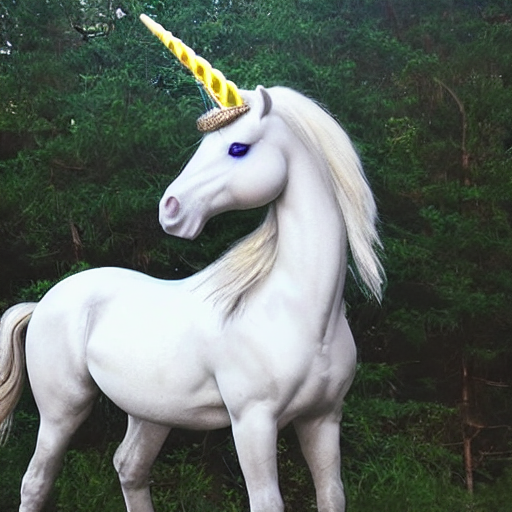

In [8]:
out[0].preds

#### attention head scaling intervention

In [12]:
spatial_location = list(range(5))
heads=list(range(4))
envoys = [block.cross_attn_out.module for block in model.unet_2.down_blocks]

# create intervention object for each combination of spatial location, head and envoy
# intervention_objs=[]
# for en in envoys:
#     for sl in spatial_location:
#         for h in heads:
#             selection = {"spatial_location":[sl],"heads":[h]}
#             intervention_objs.append(ScalingAttentionIntervention(model=model,factor=100,envoys=envoys,selection=selection))


# intervene on all of them together
intervention_objs=[]
intervention_objs.append(ScalingAttentionIntervention(model=model,factor=100,envoys=envoys,selection={"spatial_location":spatial_location,"heads":heads}))

specs=[]
for obj in intervention_objs:
    specs.append(InferenceSpec(name=f"sl{obj.selection['spatial_location'][0]}_h{obj.selection['heads'][0]}_{obj.envoys[0].__class__.__name__ if len(obj.envoys)>0 else None}", 
                               inference_fn= run_intervention,
                               kwargs={"model":model, "prompt":"unicorn", "n_steps":50, "start_step":0, "end_step":50, "seed":40, "interventions":[obj]}))

out=[]   
for spec in specs:
    inference = Inference(spec)
    out.append(inference.predict())

100%|██████████| 50/50 [00:02<00:00, 21.78it/s]
/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/nnsight/intervention/interleaver.py:276: UserWarning: Execution complete but `model.unet.down_blocks.0.attentions.0.transformer_blocks.0.attn2.output.i1` was not provided. This was in an Iterator at iteration 1 so likely this iteration did not happen. If you were using `.iter[:]`, this is likely not an error.
  warnings.warn(msg)


In [ ]:
# original image
with model.generate("unicorn", n_steps=50, seed=40) as gen:
    orig = model.output.save()
orig.images[0]    

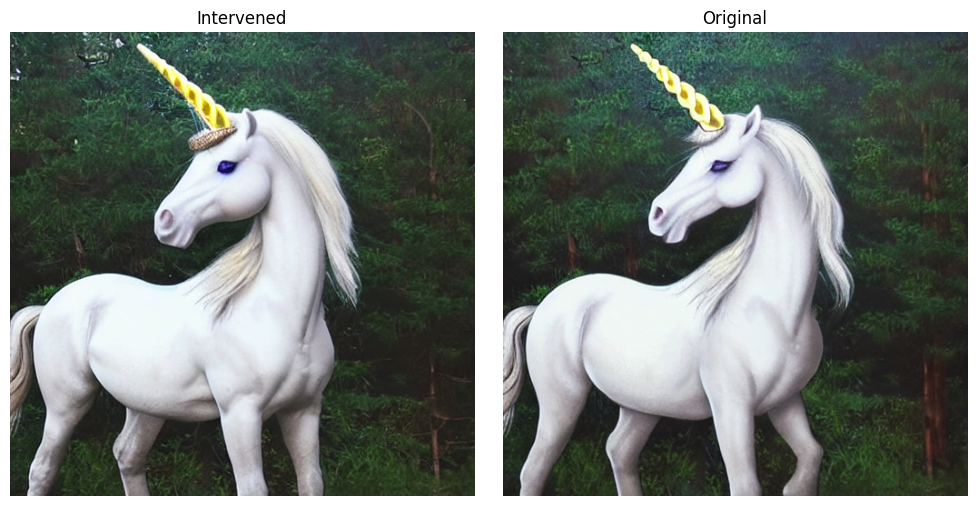

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(orig.images[0]); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(out[0].preds); ax[1].set_title("Intervened"); ax[1].axis("off")
plt.tight_layout(); plt.show()


#### Add Metrics

In [6]:
from utils.metrics import CLIPScore
intervention_objs=[]
spatial_location = list(range(5))
heads=list(range(4))
envoys = [block.cross_attn_out.module for block in model.unet_2.down_blocks]

intervention_objs.append(ScalingIntervention(model=model,factor=100,envoys=envoys,selection={"spatial_location":spatial_location,"heads":heads}))

specs=[]
for obj in intervention_objs:
    specs.append(InferenceSpec(name=f"sl{obj.selection['spatial_location'][0]}_h{obj.selection['heads'][0]}_{obj.envoys[0].__class__.__name__ if len(obj.envoys)>0 else None}", 
                               inference_fn= run_intervention, metric_fns=[CLIPScore().compute],
                               kwargs={"model":model, "prompt":"unicorn", "n_steps":50, "start_step":0, "end_step":50, "seed":40, "interventions":[obj]}))
    break

out=[]   
for spec in specs:
    inference = Inference(spec)
    out.append(inference.predict())

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
  0%|          | 0/50 [00:00<?, ?it/s]

torch.Size([2, 4096, 8, 40]) ([0, 1, 2, 3, 4], [0, 1, 2, 3])


NNsightException: 

Traceback (most recent call last):
  File "/mnt/data2/nirmal/T2I_interp/T2I_Interp_toolkit/t2Interp/intervention.py", line 123, in run_intervention
    intervention()
  File "/mnt/data2/nirmal/T2I_interp/T2I_Interp_toolkit/t2Interp/intervention.py", line 35, in __call__
    self.intervene(envoy)
  File "/mnt/data2/nirmal/T2I_interp/T2I_Interp_toolkit/t2Interp/intervention.py", line 112, in intervene
    apply(hidden_states, self.factor, selection, attn_to_out)
  File "/mnt/data2/nirmal/T2I_interp/T2I_Interp_toolkit/t2Interp/intervention.py", line 90, in apply
    hidden_states[1, selection[0], selection[1]] *= factor

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [5], [4]

#### visualize

### Issues

In [8]:
#renaming issue
from nnsight.modeling.diffusion import DiffusionModel
cfg = {'unet.down_blocks': 'downsize_blocks'} 
# cfg={'model.unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1': 'model.unet.down_blocks[0].attentions[0].transformer_blocks[0].self_attn'}
model = DiffusionModel("stable-diffusion-v1-5/stable-diffusion-v1-5", rename=cfg)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/torch/nn/modules/module.py:2441: UserWarning: for conv_in.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/torch/nn/modules/module.py:2441: UserWarning: for conv_in.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/torch/nn/modules/module.py:2441: UserWarning: for tim

### inspecting model components

In [9]:
from PIL import Image
prompt = ""

with model.generate(
            prompt,
            image=Image.new("RGB", (512, 512), color=(128,128,128)),
            guidance_scale=0.0,
            height=512,
            width=512,
            num_inference_steps=1,
            seed=17
        ):
    envoy_input = model.unet.down_blocks[0].attentions[0].transformer_blocks[0].attn2.inputs.save()
    n_heads = model.unet.down_blocks[0].attentions[0].transformer_blocks[0].attn2.heads.save()
    input2 = model.unet.down_blocks[0].attentions[0].transformer_blocks[0].attn2.to_out[0].input.save()
    

100%|██████████| 1/1 [00:01<00:00,  1.77s/it]
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


In [10]:
# envoy_input[1]['encoder_hidden_states'].shape
input2.shape

torch.Size([1, 4096, 320])

### intervention 

In [11]:
from nnsight.modeling.language import LanguageModel
other_model = LanguageModel('openai-community/gpt2', device_map='auto', rename={'transformer.h.0.mlp': 'my_mlp'})

with other_model.trace("Hello World"):

    l1 = other_model.my_mlp.output.save()

KeyboardInterrupt: 

### stitch

In [ ]:
model = DiffusionModel(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    dispatch=True
).to("cuda") #"black-forest-labs/FLUX.1-dev" stable-diffusion-v1-5/stable-diffusion-v1-5


NameError: name 'DiffusionModel' is not defined

In [ ]:
from nnsight.modeling.diffusion import DiffusionModel
import torch
model = DiffusionModel(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    dispatch=True,
    rename ={"text_encoder": "text_encoder_3"} # for dual text encoder models
)

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  8.52it/s]


In [ ]:
images=[]
with model.generate(
    "cat",
    num_inference_steps=10,
    guidance_scale=7.5,
    height=512,
    width=512,
    output_type="pil",
):
    # temp.output=(temp2[0]*0,)
    # temp.input[0] = 0 * temp.input[0]
    temp2=temp.input.save()
    
    image=model.output.images[0]
    images.append(image)
temp2 

100%|██████████| 10/10 [00:01<00:00,  5.99it/s]


In [ ]:
images[0].save("output.png")

In [ ]:
from PIL import Image
prompt = ""

with model.generate(
            prompt,
            image=Image.new("RGB", (512, 512), color=(128,128,128)),
            guidance_scale=0.0,
            height=512,
            width=512,
            num_inference_steps=1,
            seed=17
        ):

  # attention = model.text_encoder_2.encoder.block[0].layer[0].SelfAttention.q.input.save()
  # attention = model.text_encoder.text_model.encoder.layers[1].self_attn.out_proj.output.save()
  for name, module in model.named_modules():
      try:
          print(module.input.shape)
      except:
        continue    


100%|██████████| 1/1 [00:00<00:00,  3.49it/s]
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


NNsightException: 

Traceback (most recent call last):
  File "/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/nnsight/intervention/backends/execution.py", line 21, in __call__
    tracer.execute(fn)
  File "/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/nnsight/intervention/tracing/tracer.py", line 385, in execute
    self.model.interleave(self.fn, *args, **kwargs)
  File "/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/nnsight/modeling/mixins/meta.py", line 76, in interleave
    return super().interleave(fn, *args, **kwargs)
  File "/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/nnsight/intervention/envoy.py", line 736, in interleave
    self._interleaver.check_dangling_mediators()
  File "/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/nnsight/intervention/interleaver.py", line 253, in check_dangling_mediators
    for mediator in self.mediators.values():

RuntimeError: dictionary changed size during iteration

In [ ]:
print(model.unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.source)

                                    * def forward(
                                    0     self,
                                    1     hidden_states: torch.Tensor,
                                    2     encoder_hidden_states: Optional[torch.Tensor] = None,
                                    3     attention_mask: Optional[torch.Tensor] = None,
                                    4     **cross_attention_kwargs,
                                    5 ) -> torch.Tensor:
                                    6     r"""
                                    7     The forward method of the `Attention` class.
                                    8 
                                    9     Args:
                                   10         hidden_states (`torch.Tensor`):
                                   11             The hidden states of the query.
                                   12         encoder_hidden_states (`torch.Tensor`, *optional*):
                                   13    

In [ ]:
# print(model.unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.source)
prompt = "The Eiffel Tower is located in the city of"

with model.trace(prompt):

  attention = model.unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.source

print(attention)

In [ ]:
from nnsight import LanguageModel

model = LanguageModel('openai-community/gpt2', device_map='auto', attn_implementation='eager')

print(model.transformer.h[0].attn.source)

/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `PYTORCH_TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


                                       * def forward(
                                       0     self,
                                       1     hidden_states: Optional[tuple[torch.FloatTensor]],
                                       2     past_key_value: Optional[Cache] = None,
                                       3     cache_position: Optional[torch.LongTensor] = None,
                                       4     attention_mask: Optional[torch.FloatTensor] = None,
                                       5     head_mask: Optional[torch.FloatTensor] = None,
                                       6     encoder_hidden_states: Optional[torch.Tensor] = None,
                                       7     encoder_attention_mask: Optional[torch.FloatTensor] = None,
                                       8     output_attentions: Optional[bool] = False,
                                       9     **kwargs,
                                      10 ) -> tuple[Union[torch.Tensor, tuple[torc

In [ ]:
prompt = "The Eiffel Tower is located in the city of"

with model.trace(prompt):

  # attention = model.transformer.h[0].attn.source.attn_output_reshape_0.output.save()
  attention = model.text_encoder.text_model.encoder.layers[1].self_attn.q_proj.input.save()

print(attention.shape)

NNsightException: 

Traceback (most recent call last):
  File "/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/nnsight/intervention/backends/execution.py", line 21, in __call__
    tracer.execute(fn)
  File "/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/nnsight/intervention/tracing/tracer.py", line 385, in execute
    self.model.interleave(self.fn, *args, **kwargs)
  File "/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/nnsight/modeling/mixins/meta.py", line 76, in interleave
    return super().interleave(fn, *args, **kwargs)
  File "/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/nnsight/intervention/envoy.py", line 733, in interleave
    fn(*args, **kwargs)
  File "/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/nnsight/modeling/diffusion.py", line 79, in __call__
    return self._model.unet(
  File "/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/torch/nn/modules/module.py", line 1773, in _wrapped_

In [ ]:
prompt = "The Eiffel Tower"
info = {}
with model.trace(prompt,scan=True,validate=False):
  # attention = model.unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.source.parameters_keys_0.save()
    # for name in ["transformer.h[0].attn","transformer.h[0].mlp"]:
    #     try:
    #         prox = getattr(model, name).output
    #         print(prox)
    #     except AttributeError:
    #         continue
    #     shp = prox.shape  
    #     kind = "Tensor"
    #     if isinstance(shp, tuple) and not all(hasattr(s, "numel") for s in shp):
    #         kind = "tuple-like"
    #     info[name] = {"kind": kind, "shape": shp, "module_type": name}
    temp = getattr(model,"transformer.h[0].attn").output
print(info)

### hook to all modules and nnsight scan to get output type

In [ ]:
for name, mod in model._model.named_modules():
    print(name, type(mod))

 <class 'nnsight.modeling.diffusion.Diffuser'>
vae <class 'diffusers.models.autoencoders.autoencoder_kl.AutoencoderKL'>
vae.encoder <class 'diffusers.models.autoencoders.vae.Encoder'>
vae.encoder.conv_in <class 'torch.nn.modules.conv.Conv2d'>
vae.encoder.down_blocks <class 'torch.nn.modules.container.ModuleList'>
vae.encoder.down_blocks.0 <class 'diffusers.models.unets.unet_2d_blocks.DownEncoderBlock2D'>
vae.encoder.down_blocks.0.resnets <class 'torch.nn.modules.container.ModuleList'>
vae.encoder.down_blocks.0.resnets.0 <class 'diffusers.models.resnet.ResnetBlock2D'>
vae.encoder.down_blocks.0.resnets.0.norm1 <class 'torch.nn.modules.normalization.GroupNorm'>
vae.encoder.down_blocks.0.resnets.0.conv1 <class 'torch.nn.modules.conv.Conv2d'>
vae.encoder.down_blocks.0.resnets.0.norm2 <class 'torch.nn.modules.normalization.GroupNorm'>
vae.encoder.down_blocks.0.resnets.0.dropout <class 'torch.nn.modules.dropout.Dropout'>
vae.encoder.down_blocks.0.resnets.0.conv2 <class 'torch.nn.modules.conv.

In [ ]:
import torch
from collections import OrderedDict

# ---------- 1) HF Diffusers: load + force eager attention ----------
from diffusers import StableDiffusionPipeline, FluxPipeline
from diffusers.models.attention_processor import AttnProcessor

DEVICE = "cuda:0"
DTYPE  = torch.float16

MODEL_ID = "CompVis/stable-diffusion-v1-4"   # <- SD / SDXL example
# MODEL_ID = "black-forest-labs/FLUX.1-dev"     # <- FLUX example

def set_eager_attention_everywhere(pipe):
    """Swap all attention processors to vanilla matmul+softmax (eager-like)."""
    if hasattr(pipe, "unet"):
        pipe.unet.set_attn_processor(AttnProcessor())
    if hasattr(pipe, "transformer"):  # DiT / Flux
        pipe.transformer.set_attn_processor(AttnProcessor())
    # Optional: text encoders / controlnet if present
    if hasattr(pipe, "text_encoder"):
        try: pipe.text_encoder.set_attn_processor(AttnProcessor())
        except Exception: pass
    if hasattr(pipe, "text_encoder_2"):
        try: pipe.text_encoder_2.set_attn_processor(AttnProcessor())
        except Exception: pass
    if hasattr(pipe, "controlnet"):
        try: pipe.controlnet.set_attn_processor(AttnProcessor())
        except Exception: pass

# Load the right pipeline
if "FLUX" in MODEL_ID or "Flux" in MODEL_ID or "FLUX" in MODEL_ID.upper():
    pipe = FluxPipeline.from_pretrained(MODEL_ID, torch_dtype=DTYPE).to(DEVICE)
else:
    pipe = StableDiffusionPipeline.from_pretrained(MODEL_ID, torch_dtype=DTYPE).to(DEVICE)

set_eager_attention_everywhere(pipe)

# (Optional) quick verify for UNet/DiT/Flux parts that exist
try:
    assert all(isinstance(p, AttnProcessor) for p in getattr(pipe.unet, "attn_processors", {}).values())
except Exception:
    pass
try:
    assert all(isinstance(p, AttnProcessor) for p in getattr(pipe.transformer, "attn_processors", {}).values())
except Exception:
    pass

# ---------- 2) Wrap with NNsight ----------
from nnsight.modeling.diffusion import DiffusionModel
dm = DiffusionModel(pipe, dispatch=True).to(DEVICE).to(DTYPE)

In [ ]:
import sys
sys.path.append("..")
from utils.config_loader import *
cfg = build_module_mapper(model, "../config/FluxTransformer2DModel.yaml")

In [ ]:
DEVICE = "cuda:0"
DTYPE  = torch.float16

MODEL_ID = "CompVis/stable-diffusion-v1-4"   # <- SD / SDXL example



### get shapes

In [ ]:
import torch, re
from PIL import Image
from typing import Any, List, Tuple, Dict
from collections import defaultdict

def describe_kind(x: Any) -> str:
    import torch
    if isinstance(x, torch.Tensor): return "Tensor"
    if isinstance(x, (list, tuple)): return f"Tuple(len={len(x)})"
    if isinstance(x, dict): return "Dict"
    if x is None: return "None"
    return type(x).__name__

# def extract_top_shapes(x: Any) -> List[Tuple[int, ...]]:
#     """Return shapes of top-level tensors only (don't recurse deep)."""
#     import torch
#     if isinstance(x, torch.Tensor): return [tuple(x.shape)]
#     if isinstance(x, (list, tuple)): return [tuple(t.shape) for t in x if hasattr(t, "shape")]
#     if isinstance(x, dict): return [tuple(v.shape) for v in x.values() if hasattr(v, "shape")]
#     return []

# def iter_diffusers_modules(pipe, components=("unet","vae","text_encoder","text_encoder_2","transformer"),
#                            leaf_only=True):
#     """Yield (qualified_path, module) across selected components."""
#     for comp in components:
#         obj = getattr(pipe, comp, None)
#         if obj is None: 
#             continue
#         for name, mod in obj.named_modules():
#             if name == "":  # skip the component root
#                 continue
#             if leaf_only and any(True for _ in mod.children()):
#                 continue
#             yield f"{comp}.{name}", mod

def scan_pipeline_modules(pipe, call_kwargs: Dict[str, Any],device="cuda"):
    """Attach forward hooks, run once, collect input/output kinds + shapes."""
    hooks = []
    results = {}
    # seen_ids = set()  # dedupe shared/tied modules

    def make_hook(path):
        def _hook(m, inputs, output):
            print(f"Hooked: {path}")
            # inputs is always a tuple from PyTorch
            in_kinds = describe_kind(inputs)
            # in_shapes = []
            # for i in inputs:
            #     in_shapes += extract_top_shapes(i)
            out_kind  = describe_kind(output)
            # out_shapes = extract_top_shapes(output)
            results[path] = {
                "path": path,
                "in_kinds": in_kinds,
                # "in_shapes": in_shapes,
                "out_kind": out_kind,
                # "out_shapes": out_shapes,
            }
        return _hook

    # Register hooks
    # for path, mod in iter_diffusers_modules(pipe, include_components, leaf_only):
    for path, mod in pipe.named_modules():
        # mid = id(mod)
        # if mid in seen_ids: 
        #     continue
        # seen_ids.add(mid)
        hooks.append(mod.register_forward_hook(make_hook(path)))

    # One forward pass
    pipe.to(device)
    with torch.no_grad():
        _ = pipe(**call_kwargs)

    # Cleanup
    for h in hooks:
        h.remove()
    print(results)
    # Sorted list for readability
    return [results[k] for k in sorted(results.keys())]

In [ ]:
from diffusers import StableDiffusionImg2ImgPipeline, DiffusionPipeline
import torch
from PIL import Image
from nnsight.modeling.diffusion import DiffusionModel

# Load
# pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
#     "CompVis/stable-diffusion-v1-4",
#     torch_dtype=torch.float16
# ).to("cuda")

def load(id: str = "CompVis/stable-diffusion-v1-4"):
    
    return DiffusionModel(id, dispatch=True).to('cuda:0').to(torch.float16)

pipe=load("CompVis/stable-diffusion-v1-4")._model

# Dummy input image (solid gray 512x512) — or load your own with Image.open(...).convert("RGB")
init_image = Image.new("RGB", (512, 512), color=(128,128,128))

records = scan_pipeline_modules(
    pipe,
    call_kwargs=dict(
        prompt="",
        image=init_image,
        strength=0.35,          # lower = preserve more of the init image
        guidance_scale=7.5,
        num_inference_steps=2,  # small for a quick scan
    ),
    device="cuda",
)

# Peek
for r in records[:20]:
    print(r)
print(f"\nTotal modules recorded: {len(records)}")


Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 21.71it/s]


Hooked: 
{'': {'path': '', 'in_kinds': 'Tuple(len=0)', 'out_kind': 'Tuple(len=2)'}}
{'path': '', 'in_kinds': 'Tuple(len=0)', 'out_kind': 'Tuple(len=2)'}

Total modules recorded: 1


In [ ]:
for path, mod in pipe.named_modules():
    mod.register_forward_hook(lambda m, i, o: print(f"{path}: {describe_kind(i)} -> {describe_kind(o)}"))

call_kwargs=dict(
        prompt="",
        image=init_image,
        strength=0.35,          # lower = preserve more of the init image
        guidance_scale=7.5,
        num_inference_steps=2,  # small for a quick scan
    ),    
with torch.no_grad():
    _ = pipe(call_kwargs)    

safety_checker.visual_projection: Tuple(len=1) -> Tuple(len=1)
safety_checker.visual_projection: Tuple(len=1) -> Tuple(len=1)


In [ ]:
# import transformers
# for path, mod in pipe.named_modules():
#     if type(mod) == transformers.models.clip.modeling_clip.CLIPEncoderLayer:
#         mod.register_forward_hook(lambda m, i, o: print(f"{path}: {describe_kind(i)} -> {describe_kind(o)}"))

pipe.text_encoder.register_forward_hook(lambda m, i, o: print(f"text_encoder: {describe_kind(i)} -> {describe_kind(o)}"))        
with torch.no_grad():
    _ = pipe(call_kwargs)         

safety_checker.visual_projection: Tuple(len=1) -> Tuple(len=1)
safety_checker.visual_projection: Tuple(len=1) -> Tuple(len=1)


In [ ]:
import torch, re
from typing import Any, Dict, List, Tuple, Iterable

# ---------- helpers ----------
def kind(x: Any) -> str:
    if isinstance(x, torch.Tensor): return "Tensor"
    if isinstance(x, (list, tuple)): return f"Tuple(len={len(x)})"
    if isinstance(x, dict): return "Dict"
    if x is None: return "None"
    return type(x).__name__

def top_shapes(x: Any) -> List[Tuple[int, ...]]:
    if isinstance(x, torch.Tensor):
        return [tuple(x.shape)]
    if isinstance(x, (list, tuple)):
        return [tuple(t.shape) for t in x if hasattr(t, "shape")]
    if isinstance(x, dict):
        return [tuple(v.shape) for v in x.values() if hasattr(v, "shape")]
    return []

def is_leaf(m: torch.nn.Module) -> bool:
    try:
        next(m.children())
        return False
    except StopIteration:
        return True

# ---------- hook everything ----------
def attach_all_hooks(
    root: torch.nn.Module,
    leaf_only: bool = True,
    include: Iterable[str] | None = None,
    exclude: Iterable[str] | None = ("safety_checker.",),  # set to None if you want those too
    regex: bool = False,
):
    """
    Returns (handles, results). results[name] = {
        'path','in_kinds','in_shapes','kw_kinds','kw_shapes','out_kind','out_shapes'
    }
    """
    results: Dict[str, Dict] = {}
    handles: List[torch.utils.hooks.RemovableHandle] = []
    seen = set()

    def match(name: str) -> bool:
        if include:
            ok = any((re.search(p, name) if regex else (p in name)) for p in include)
            if not ok: return False
        if exclude:
            bad = any((re.search(p, name) if regex else (p in name)) for p in exclude)
            if bad: return False
        return True

    # pre-hook to capture kwargs too
    def make_pre_hook(path: str):
        def _pre(m, args, kwargs, _path=path):
            rec = results.get(_path, {"path": _path})
            rec["in_kinds"]  = [kind(a) for a in args]
            in_shapes = []
            for a in args: in_shapes += top_shapes(a)
            rec["in_shapes"] = in_shapes

            # kwargs support (handles your Tuple(len=0) case)
            rec["kw_kinds"]  = {k: kind(v) for k, v in kwargs.items()}
            rec["kw_shapes"] = {k: top_shapes(v) for k, v in kwargs.items()}
            results[_path] = rec
        return _pre

    def make_fwd_hook(path: str):
        def _hook(m, inputs, output, _path=path):
            rec = results.get(_path, {"path": _path})
            rec["out_kind"]   = kind(output)
            rec["out_shapes"] = top_shapes(output)
            results[_path] = rec
        return _hook

    for name, mod in root.named_modules():
        if name == "":  # skip root
            continue
        if leaf_only and not is_leaf(mod):
            continue
        if not match(name):
            continue
        mid = id(mod)
        if mid in seen:
            continue
        seen.add(mid)

        # Pre-hook with kwargs; forward hook for output
        handles.append(mod.register_forward_pre_hook(make_pre_hook(name), with_kwargs=True))
        handles.append(mod.register_forward_hook(make_fwd_hook(name), with_kwargs=False))

    return handles, results


# ---------- example usage ----------
# `pipe` here is YOUR Diffuser(...) nn.Module
# choose run that actually exercises paths you care about:
# - txt2img: runs text_encoder + UNet + VAE.decoder (NOT VAE.encoder)
# - img2img/inpaint: runs text_encoder + UNet + VAE.encoder + VAE.decoder

# 1) attach hooks to everything (or set leaf_only=True to reduce spam)
handles, results = attach_all_hooks(
    pipe,
    leaf_only=False,                 # flip to False to include composite modules too
    include=None,                   # e.g., ("unet.", "vae.encoder.")
    exclude=None,                   # set to ("safety_checker.",) if you want to skip it
    regex=False
)

# Choose a path that actually exercises modules you care about:
# - txt2img: text_encoder + unet + vae.decoder (NOT vae.encoder)
# - img2img/inpaint: text_encoder + unet + vae.encoder + vae.decoder
from PIL import Image
init_img = Image.new("RGB", (512, 512), (128,128,128))

with torch.no_grad():
    _ = pipe(
        prompt="a sketch of a cat",
        image=init_img,            # remove this line for pure txt2img
        strength=0.35,
        guidance_scale=7.5,
        num_inference_steps=2,
    )

for h in handles: h.remove()

# Inspect
keys = sorted(results.keys())
print("Total modules recorded:", len(keys))
for k in keys[:20]:
    r = results[k]
    print(
        f"{r['path']}: "
        f"args {r.get('in_kinds',[])} {r.get('in_shapes',[])} | "
        f"kwargs { {k:v for k,v in r.get('kw_kinds',{}).items()} } "
        f"-> {r.get('out_kind')} {r.get('out_shapes')}"
    )


safety_checker.visual_projection: Tuple(len=0) -> Tuple(len=2)
safety_checker.visual_projection: Tuple(len=0) -> Tuple(len=2)
Total modules recorded: 0


In [ ]:
import torch

def make_fwd_hook(path: str):
        def _hook(m, inputs, output, _path=path):
            rec = results.get(_path, {"path": _path})
            rec["out_kind"]   = kind(output)
            rec["out_shapes"] = top_shapes(output)
            results[_path] = rec
        return _hook
    
# def make_hook(tag):
#     def _hook(m, i, o):
#         def k(x):
#             if isinstance(x, torch.Tensor): return f"T{tuple(x.shape)}"
#             if isinstance(x, (list, tuple)): return f"Tuple{len(x)}"
#             if isinstance(x, dict): return "Dict"
#             return type(x).__name__
#         ins = [k(x) for x in i]
#         out = k(o)
#         print(f"[HOOK] {tag}: {ins} -> {out}")
#     return _hook

# Pick something that always runs:
# h = pipe.unet.conv_in.register_forward_hook(make_hook("unet.conv_in"))
for name, mod in pipe.named_modules():
        handles.append(mod.register_forward_hook(make_fwd_hook(name), with_kwargs=False))

# Run a path that executes UNet (both txt2img and img2img work)
with torch.no_grad():
    _ = pipe(prompt="a cat", num_inference_steps=2, guidance_scale=7.5)

h.remove()


safety_checker.visual_projection: Tuple(len=0) -> Tuple(len=2)
safety_checker.visual_projection: Tuple(len=0) -> Tuple(len=2)


In [ ]:
from diffusers import StableDiffusionImg2ImgPipeline, DiffusionPipeline
import torch
from PIL import Image
from nnsight.modeling.diffusion import DiffusionModel

def load(id: str = "CompVis/stable-diffusion-v1-4"):
    
    return DiffusionModel(id, dispatch=True).to('cuda:0').to(torch.float16)

pipe=load("CompVis/stable-diffusion-v1-4")._model

/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nirmal/miniconda3/envs/viz/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `PYTORCH_TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 19.35it/s]


In [ ]:
for name, mod in pipe.named_modules():
    # print(isinstance(mod, torch.nn.Module))
    mod.register_forward_hook(lambda m, i, o: print("here"))
    
pipe(prompt="a cat", num_inference_steps=2, guidance_scale=7.5)    

here


((), {'prompt': 'a cat', 'num_inference_steps': 2, 'guidance_scale': 7.5})

In [ ]:
for name, mod in pipe.named_modules():
    if name == "unet.mid_block.attentions.0.transformer_blocks.0.ff.net.0":
        mod.proj.register_forward_hook(lambda m, i, o: print("here"))
pipe(prompt="a cat", num_inference_steps=2, guidance_scale=7.5)          

here


((), {'prompt': 'a cat', 'num_inference_steps': 2, 'guidance_scale': 7.5})

In [ ]:
for name, mod in pipe.named_modules():
    # if name == "unet.mid_block.attentions.0.transformer_blocks.0.ff.net.0":
    #     print(mod)
    if "k_proj" in name.lower():
        print(name,mod)
        mod.register_forward_hook(lambda m, i, o: print("here"))
        break

text_encoder.text_model.encoder.layers.0.self_attn.k_proj Linear(in_features=768, out_features=768, bias=True)


In [ ]:
import torch, re
from PIL import Image
from typing import Any, List, Tuple, Dict
from collections import defaultdict

def describe_kind(x: Any) -> str:
    import torch
    if isinstance(x, torch.Tensor): return "Tensor"
    if isinstance(x, (list, tuple)): return f"Tuple(len={len(x)})"
    if isinstance(x, dict): return "Dict"
    if x is None: return "None"
    return type(x).__name__

def extract_top_shapes(x: Any) -> List[Tuple[int, ...]]:
    """Return shapes of top-level tensors only (don’t recurse deep)."""
    import torch
    if isinstance(x, torch.Tensor): return [tuple(x.shape)]
    if isinstance(x, (list, tuple)): return [tuple(t.shape) for t in x if hasattr(t, "shape")]
    if isinstance(x, dict): return [tuple(v.shape) for v in x.values() if hasattr(v, "shape")]
    return []

def iter_diffusers_modules(pipe, components=("unet","vae","text_encoder","text_encoder_2","transformer"),
                           leaf_only=True):
    """Yield (qualified_path, module) across selected components."""
    for comp in components:
        obj = getattr(pipe, comp, None)
        if obj is None: 
            continue
        for name, mod in obj.named_modules():
            if name == "":  # skip the component root
                continue
            if leaf_only and any(True for _ in mod.children()):
                continue
            yield f"{comp}.{name}", mod

def scan_pipeline_modules(pipe, call_kwargs: Dict[str, Any],
                          include_components=("unet","vae","text_encoder","text_encoder_2","transformer"),
                          leaf_only=True, device="cuda"):
    """Attach forward hooks, run once, collect input/output kinds + shapes."""
    hooks = []
    results = {}
    seen_ids = set()  # dedupe shared/tied modules

    def make_hook(path):
        def _hook(m, inputs, output):
            # inputs is always a tuple from PyTorch
            in_kinds = describe_kind(inputs)
            in_shapes = []
            for i in inputs:
                in_shapes += extract_top_shapes(i)
            out_kind  = describe_kind(output)
            out_shapes = extract_top_shapes(output)
            results[path] = {
                "path": path,
                "in_kinds": in_kinds,
                # "in_shapes": in_shapes,
                "out_kind": out_kind,
                # "out_shapes": out_shapes,
            }
        return _hook

    # Register hooks
    for path, mod in iter_diffusers_modules(pipe, include_components, leaf_only):
        mid = id(mod)
        if mid in seen_ids: 
            continue
        seen_ids.add(mid)
        hooks.append(mod.register_forward_hook(make_hook(path)))

    # One forward pass
    pipe.to(device)
    with torch.no_grad():
        _ = pipe(**call_kwargs)

    # Cleanup
    for h in hooks:
        h.remove()

    # Sorted list for readability
    return [results[k] for k in sorted(results.keys())]


In [ ]:
from diffusers import StableDiffusionImg2ImgPipeline
import torch
from PIL import Image

# Load
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

# Dummy input image (solid gray 512x512) — or load your own with Image.open(...).convert("RGB")
init_image = Image.new("RGB", (512, 512), color=(128,128,128))

records = scan_pipeline_modules(
    pipe,
    call_kwargs=dict(
        prompt="a simple sketch of a cat",
        image=init_image,
        strength=0.35,          # lower = preserve more of the init image
        guidance_scale=7.5,
        num_inference_steps=2,  # small for a quick scan
    ),
    include_components=("unet","vae","text_encoder"),  # tweak as you like
    leaf_only=True,
    device="cuda",
)

# Peek
for r in records:
    print(r)
print(f"\nTotal modules recorded: {len(records)}")


Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 10.17it/s]
1it [00:00, 30.88it/s]

{'path': 'text_encoder.text_model.embeddings.position_embedding', 'in_kinds': 'Tuple(len=1)', 'out_kind': 'Tensor'}
{'path': 'text_encoder.text_model.embeddings.token_embedding', 'in_kinds': 'Tuple(len=1)', 'out_kind': 'Tensor'}
{'path': 'text_encoder.text_model.encoder.layers.0.layer_norm1', 'in_kinds': 'Tuple(len=1)', 'out_kind': 'Tensor'}
{'path': 'text_encoder.text_model.encoder.layers.0.layer_norm2', 'in_kinds': 'Tuple(len=1)', 'out_kind': 'Tensor'}
{'path': 'text_encoder.text_model.encoder.layers.0.mlp.activation_fn', 'in_kinds': 'Tuple(len=1)', 'out_kind': 'Tensor'}
{'path': 'text_encoder.text_model.encoder.layers.0.mlp.fc1', 'in_kinds': 'Tuple(len=1)', 'out_kind': 'Tensor'}
{'path': 'text_encoder.text_model.encoder.layers.0.mlp.fc2', 'in_kinds': 'Tuple(len=1)', 'out_kind': 'Tensor'}
{'path': 'text_encoder.text_model.encoder.layers.0.self_attn.k_proj', 'in_kinds': 'Tuple(len=1)', 'out_kind': 'Tensor'}
{'path': 'text_encoder.text_model.encoder.layers.0.self_attn.out_proj', 'in_ki